In [11]:
# Necessary imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import ttest_1samp
from scipy.stats import f_oneway
import seaborn as sns

In [12]:
# Setting up database
stocks_df = pd.read_csv("faang_stock_prices.csv")
stocks_df['Date'] = pd.to_datetime(stocks_df['Date'])

# Organization just in case of random unordered data. Initial csv seems to be ordered by date already
stocks_df = stocks_df.sort_values(by = "Date").dropna()

display(stocks_df)

,Date,Ticker,Open,High,Low,Close,Volume,SMA_7,SMA_21,EMA_12,EMA_26,RSI_14,MACD,MACD_Signal,Bollinger_Upper,Bollinger_Lower,Daily_Return,Volatility_7d,Next_Day_Close
0,2016-02-23,AAPL,21.853144,21.875812,21.433763,21.465500,127770400,21.782546,21.682435,21.720115,21.827292,52.112369,-0.107176,-0.149939,22.401531,20.889519,-0.022605,0.018130,21.785145
1,2016-02-23,AMZN,27.777500,27.845501,27.266500,27.646999,81016000,26.675857,27.140333,26.765295,27.363824,50.230010,-0.598529,-0.896261,31.103668,22.908382,-0.011725,0.022486,27.702000
2,2016-02-23,GOOGL,36.032746,36.270944,35.515157,35.595547,41332000,35.747473,36.132564,35.810892,36.019909,28.846871,-0.209017,-0.219158,38.439218,33.798573,-0.016131,0.015153,35.774696
3,2016-02-23,META,106.108789,106.724491,104.390794,104.728432,25319300,103.488525,103.976073,103.607174,102.390311,34.031434,1.216863,1.318966,115.829165,92.886882,-0.015864,0.019720,106.138588
4,2016-02-23,MSFT,46.158514,46.184970,44.959133,45.135513,28895300,45.542440,45.303900,45.301104,45.262960,42.877882,0.038144,-0.096534,48.143898,42.459504,-0.027920,0.019161,45.294239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14958,2026-01-22,AAPL,249.199997,251.000000,248.149994,248.350006,39708300,253.921424,263.157615,256.309211,262.339803,11.871533,-6.030592,-4.355544,280.781111,244.752881,0.002827,0.013499,248.039993
14959,2026-01-22,AMZN,234.050003,235.720001,230.899994,234.339996,31913300,236.171426,236.013333,236.263937,235.039321,53.529872,1.224615,2.202436,248.520707,224.264292,0.013099,0.017721,239.160004
14960,2026-01-22,GOOGL,334.450012,335.149994,328.750000,330.540009,26253600,330.787144,321.977620,326.886086,320.764595,67.582193,6.121491,6.383337,339.589684,305.585319,0.006578,0.014879,327.929993
14961,2026-01-22,META,629.349976,660.570007,626.549988,647.630005,21394700,621.767151,645.427618,632.259363,640.510804,45.687381,-8.251442,-5.985550,684.649099,604.598899,0.056562,0.028988,658.760010


In [13]:
display(stocks_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 14964 entries, 0 to 14963
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             14964 non-null  datetime64[ns]
 1   Ticker           14964 non-null  object        
 2   Open             14964 non-null  float64       
 3   High             14964 non-null  float64       
 4   Low              14964 non-null  float64       
 5   Close            14964 non-null  float64       
 6   Volume           14964 non-null  int64         
 7   SMA_7            14964 non-null  float64       
 8   SMA_21           14964 non-null  float64       
 9   EMA_12           14964 non-null  float64       
 10  EMA_26           14964 non-null  float64       
 11  RSI_14           14964 non-null  float64       
 12  MACD             14964 non-null  float64       
 13  MACD_Signal      14964 non-null  float64       
 14  Bollinger_Upper  14964 non-null  float64   

None

**Method 1: Checking The Mean Daily Return of AAPL Stock**

In [14]:
# First, we're gonna extract the data that we need.

aapl = stocks_df[stocks_df["Ticker"] == "AAPL"]["Daily_Return"]

Before we do a T-Test, let's list out the null and alternative hypothesis:

> Null Hypothesis: The mean daily return of the AAPL stock is 0.
> Alternative Hypothesis: The mean daily return of the AAPL stock differs from 0.

In [15]:
# Next, we're gonna do a T-Test on the returns for the AAPL stock.

t_stat, p_value = ttest_1samp(aapl, 0)

print("Mean Return: ", aapl.mean())
print("T-statistic: ", t_stat)
print("P-value: ", p_value)

Mean Return:  0.001138375316073588
T-statistic:  3.12303182632681
P-value:  0.0018105315125036081


Based on the P-value of 0.0018, since this P-value is significantly smaller than the alpha level of 0.05 (0.0018 < 0.05), we reject the null hypothesis. This indicates that there is storng evidence th e mean daily return of AAPL is different from zero. Therefore, we can state that AAPL exhibits a statistically siginficant average return, suggesting the presence of a trend in returns rather than just stable at 0.

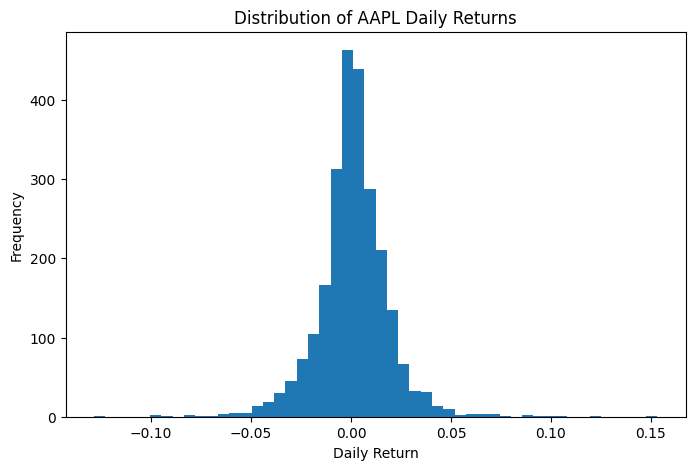

In [16]:
# Now, let's provide a plot to show this trend in average daily return.

plt.figure(figsize=(8,5))
plt.hist(aapl, bins = 50)

plt.title("Distribution of AAPL Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

Looking at the histogram distribution of daily returns for the AAPL stock, we see that it seems to be approximately centered around 0. Although this seems to visually be the case, the mean return is slightly different from zero based on the t-test (0.0011). The difference is too small to be visually noticeable on the histogram since there are so many samples. The larger the sample size, the smaller the difference from the null hypothesis to be significant, as more samples should theoretically allow us to get more accurate results. As a result, the test finds that the mean return is statistically significant despite looking close to 0 on the plot.

**Method 2: Group Comparison**


In [17]:
avg_returns = stocks_df.groupby('Ticker')['Daily_Return'].mean()
print(avg_returns)

Ticker
AAPL     0.001138
AMZN     0.001061
GOOGL    0.001052
META     0.001017
MSFT     0.001053
NVDA     0.002688
Name: Daily_Return, dtype: float64


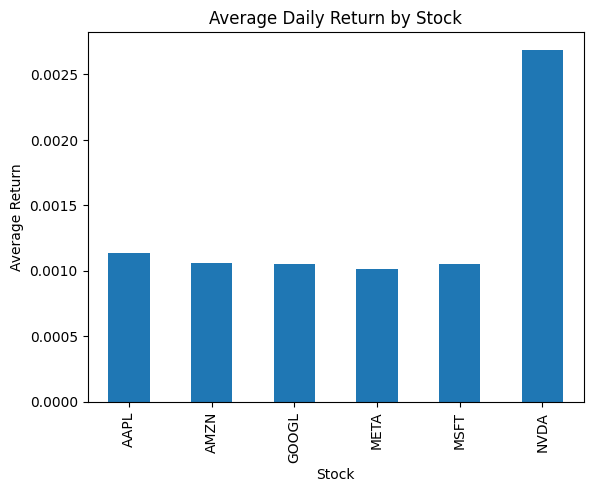

In [18]:
avg_returns.plot(kind='bar')
plt.title("Average Daily Return by Stock")
plt.xlabel("Stock")
plt.ylabel("Average Return")
plt.show()

Looking at the bar chart, I see that NVDA has the highest average daily return among all stocks. It is almost double compared to every other stock. The other stocks (AAPL, AMZN, GOOGL, META, MSFT) have almost similar average returns, all around 0.001. So this is the average for good companies but NVDA is an outlier with its .0025
This can mean that NVDA has a higher return on average, but this could also come with higher risk. In contrast, the other stocks appear more stable with consistent but lower returns.

**Method 3: One-Way ANOVA, Comparing Mean Daily Returns Across FAANG+ Tickers**

We want to determine whether the mean daily return differs significantly across all six 
tickers (AAPL, AMZN, GOOGL, META, MSFT, NVDA).

Before running the ANOVA test, let's state our hypotheses:

> **Null Hypothesis (H₀):** The mean daily return is the same across all FAANG+ tickers.  
> **Alternative Hypothesis (H₁):** At least one ticker has a significantly different mean daily return.

In [19]:
# Group Daily_Return by Ticker
groups = [group['Daily_Return'].dropna().values 
          for _, group in stocks_df.groupby('Ticker')]

# One-Way ANOVA
f_stat, p_value = f_oneway(*groups)

print("F-statistic: ", f_stat)
print("P-value:     ", p_value)

F-statistic:  2.2607764069337417
P-value:      0.04573257958187556


Since the P-value is less than our alpha level of 0.05, we reject the null hypothesis.
This means there is statistically significant evidence that at least one FAANG+ ticker 
has a different mean daily return from the others. This aligns with what we observed 
visually in Method 2, where NVDA stood out with a notably higher average return (~0.0027) 
compared to the rest (~0.001).

/var/folders/25/7hdh1xtj4y90y90bmnz9pl880000gn/T/ipykernel_48783/735152299.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


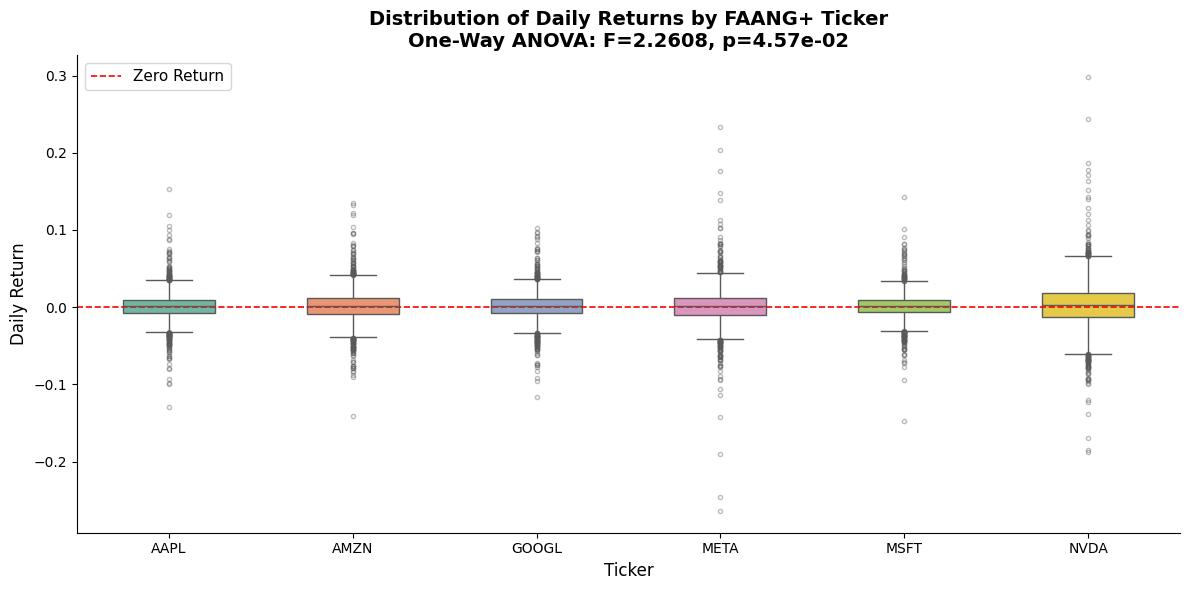

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=stocks_df,
    x='Ticker',
    y='Daily_Return',
    width=0.5,
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    ax=ax
)

ax.axhline(0, color='red', linestyle='--', linewidth=1.2, label='Zero Return')

ax.set_title(
    f'Distribution of Daily Returns by FAANG+ Ticker\n'
    f'One-Way ANOVA: F={f_stat:.4f}, p={p_value:.2e}'
)
ax.set_xlabel('Ticker', fontsize=12)
ax.set_ylabel('Daily Return', fontsize=12)
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

The box plot displays the median (center line), interquartile range (box), and 
whiskers (1.5x IQR) for each FAANG+ ticker's daily returns. Small dots beyond 
the whiskers are outliers. All tickers are centered near 0, but NVDA has a 
noticeably taller box and more extreme outliers in both directions, confirming 
its higher average return and higher volatility compared to the other five stocks. 
The red dashed line at 0 serves as a reference, all six tickers sit above it on 
average, indicating consistent positive returns over the dataset's time range.